# Laboratorio ML — Pipeline de Forecasting

Hilo de ejecución completo que espeja exactamente `src/services/ml_predictivo.py`.
Cada fase imprime la **forma de la matriz** y un **sample** antes y después de la transformación.

| Fase | Qué hace |
|------|----------|
| 0 | Configuración e imports |
| 1 | Carga datos brutos |
| 2 | Selección de zona objetivo |
| 3 | Enriquecimiento climático (Open-Meteo) |
| 4 | Feature engineering base (calendario, lags, clima) |
| 5 | Supercalendario comercial |
| 6 | Matriz final + correlaciones |
| 7 | Split temporal + entrenamiento XGBoost |
| 8 | Importancia de features |
| 9 | Predicción autorregresiva (backtesting) |
| 10 | Evaluación de métricas |
---

In [ ]:
# FASE 0 — Configuración
import os
import sys

sys.path.insert(0, os.path.abspath('../..'))

import json
import warnings
from datetime import timedelta

import holidays
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

warnings.filterwarnings('ignore')

from src.data_processing.supercalendario import CALENDARIO_FEATURE_COLS, get_calendario_features

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')

festivos_espana = holidays.ES(years=[2024, 2025, 2026])

# ── Parámetros de simulación ──────────────────────────────────────────────────
FECHA_CORTE  = pd.to_datetime('2026-04-01')   # falso_hoy
HORIZONTE    = 14                              # días hacia adelante
UUID_LOC     = '67034276-0d01-4c90-a363-fa75699a19a4'  # Malaga Muelle 1
UUID_ZONA    = '79c9c568-41e1-43b3-84d4-e413630fa58a'  # Calle
CSV_PATH     = '../data/dataset_alvaro.csv'
JSON_PATH    = '../data/todas_las_ubicaciones.json'

print(f'Zona objetivo : {UUID_LOC}')
print(f'Fecha de corte: {FECHA_CORTE.date()}  |  Horizonte: {HORIZONTE} días')

## Fase 1 — Carga de datos brutos

In [2]:
df_raw = pd.read_csv(CSV_PATH)
df_raw['fecha'] = pd.to_datetime(df_raw['fecha'])

print(f'Shape : {df_raw.shape}')
print(f'Fechas: {df_raw["fecha"].min().date()} → {df_raw["fecha"].max().date()}')
print(f'Locs  : {df_raw["location_id"].nunique()} ubicaciones  |  {df_raw["zone_uuid"].nunique()} zonas')
print()
display(df_raw.dtypes.to_frame('dtype'))
display(df_raw.head(3))

Shape : (6847, 17)
Fechas: 2025-01-01 → 2026-05-29
Locs  : 5 ubicaciones  |  30 zonas



,dtype
fecha,datetime64[us]
location_id,str
zone_uuid,str
total_visits,int64
unique_visitors,int64
new_visitors,float64
uv_7d,float64
uv_28d,float64
uv_month,float64
uv_year,float64


,fecha,location_id,zone_uuid,total_visits,unique_visitors,new_visitors,uv_7d,uv_28d,uv_month,uv_year,freq_7d,freq_28d,freq_month,freq_year,dwell_time,dwell_hist,hourly_visits
0,2026-05-22,db01e2ed-3bbb-4c6f-8bbe-9b73762f473d,ad0a5f72-a9ff-4ed1-ad94-b58395038eab,25280,16240,5611.0,86536.0,296271.0,244375.0,1038323.0,1.098525,1.264848,1.230813,1.682635,285,"[{'minutes': 'd_000_002', 'value': 9744}, {'mi...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 986, 1334, 1624..."
1,2026-05-22,db01e2ed-3bbb-4c6f-8bbe-9b73762f473d,d29dfc9f-0217-4a80-abfe-c54e6939f216,268,268,232.0,1587.0,5749.0,4712.0,28412.0,1.009132,1.021438,1.024615,1.087522,243,"[{'minutes': 'd_000_010', 'value': 101}, {'min...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 29, 21, 21, 0, ..."
2,2026-05-22,db01e2ed-3bbb-4c6f-8bbe-9b73762f473d,47852e02-201b-44a9-bfa8-f045ac686e49,44,44,44.0,691.0,2319.0,2029.0,9299.0,1.000000,1.000000,1.000000,1.107914,141,"[{'minutes': 'd_000_002', 'value': 0}, {'minut...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 22, 0, 0, 0, 0,..."


## Fase 2 — Selección de zona objetivo

In [3]:
# Lectura del JSON de ubicaciones para nombre y coordenadas
with open(JSON_PATH, encoding='utf-8') as f:
    datos_loc = json.load(f)

mapa_nombres, mapa_coords = {}, {}
for org in datos_loc:
    for loc in org.get('locations', []):
        mapa_nombres[loc['uuid']] = loc['name']
        if 'lat' in loc and 'lon' in loc:
            mapa_coords[loc['uuid']] = (loc['lat'], loc['lon'])

nombre_loc = mapa_nombres.get(UUID_LOC, UUID_LOC)
lat, lon   = mapa_coords.get(UUID_LOC, (36.7186, -4.4131))
print(f'Ubicación: {nombre_loc}  (lat={lat}, lon={lon})')

df_tienda = df_raw[
    (df_raw['location_id'] == UUID_LOC) &
    (df_raw['zone_uuid']   == UUID_ZONA)
].copy()

df_tienda = (
    df_tienda
    .groupby('fecha')
    .agg(total_visits=('total_visits', 'sum'))
    .reset_index()
    .sort_values('fecha')
    .reset_index(drop=True)
)

print(f'\nDías en zona: {len(df_tienda)}')
display(df_tienda.describe())

Ubicación: Malaga Muelle 1  (lat=36.7186, lon=-4.4131)

Días en zona: 270


,fecha,total_visits
count,270,270.000000
mean,2026-01-14 12:00:00,10707.814815
min,2025-09-02 00:00:00,0.000000
25%,2025-11-08 06:00:00,8590.000000
50%,2026-01-14 12:00:00,11056.500000
75%,2026-03-22 18:00:00,13640.500000
max,2026-05-29 00:00:00,21689.000000
std,NaN,4647.297375


## Fase 3 — Enriquecimiento climático (Open-Meteo)

In [4]:
fecha_min = df_tienda['fecha'].min().strftime('%Y-%m-%d')
fecha_max = df_tienda['fecha'].max().strftime('%Y-%m-%d')

url = (
    f'https://archive-api.open-meteo.com/v1/archive'
    f'?latitude={lat}&longitude={lon}'
    f'&start_date={fecha_min}&end_date={fecha_max}'
    f'&daily=temperature_2m_max,temperature_2m_min,precipitation_sum'
    f'&timezone=Europe%2FMadrid'
)
print('Fetching Open-Meteo...')
resp = requests.get(url).json()

df_clima = pd.DataFrame({
    'fecha'       : pd.to_datetime(resp['daily']['time']),
    'temp_max'    : resp['daily']['temperature_2m_max'],
    'temp_min'    : resp['daily']['temperature_2m_min'],
    'precipitacion': resp['daily']['precipitation_sum'],
})
df_clima['llueve'] = (df_clima['precipitacion'] > 0).astype(int)

df_tienda = df_tienda.merge(df_clima[['fecha','temp_max','temp_min','llueve']], on='fecha', how='left')
df_tienda['es_festivo'] = df_tienda['fecha'].apply(lambda d: 1 if d in festivos_espana else 0)

print(f'Shape tras clima: {df_tienda.shape}')
print(f'NaN en clima    : {df_tienda[["temp_max","temp_min","llueve"]].isna().sum().to_dict()}')
display(df_tienda.head(4))

Fetching Open-Meteo...
Shape tras clima: (270, 6)
NaN en clima    : {'temp_max': 0, 'temp_min': 0, 'llueve': 0}


,fecha,total_visits,temp_max,temp_min,llueve,es_festivo
0,2025-09-02,12850,30.4,20.5,0,0
1,2025-09-03,12949,29.5,20.9,0,0
2,2025-09-04,12963,29.2,19.6,0,0
3,2025-09-05,13695,28.8,21.2,0,0


## Fase 4 — Feature Engineering base (calendario, lags, clima)

In [5]:
train = df_tienda[df_tienda['fecha'] < FECHA_CORTE].copy()
print(f'Train antes de lags: {len(train)} filas')

# ── Features de calendario ────────────────────────────────────────────────────
train['es_finde']        = train['fecha'].dt.dayofweek.isin([5, 6]).astype(int)
train['dia_semana']      = train['fecha'].dt.dayofweek
train['dia_mes']         = train['fecha'].dt.day
train['mes']             = train['fecha'].dt.month
train['quincena']        = (train['dia_mes'] > 15).astype(int)
train['vispera_festivo'] = train['fecha'].apply(
    lambda d: 1 if (d + timedelta(days=1)) in festivos_espana else 0
)

# ── Features de clima ─────────────────────────────────────────────────────────
train['mucho_calor']  = (train['temp_max'] >= 32.0).astype(int)
train['mucho_frio']   = (train['temp_min'] <= 8.0).astype(int)
train['clima_ideal']  = (
    (train['temp_max'] >= 18.0) & (train['temp_max'] <= 26.0) & (train['llueve'] == 0)
).astype(int)
train['finde_lluvioso'] = train['es_finde'] * train['llueve']

# ── Lags y rolling stats ──────────────────────────────────────────────────────
train['lag_1d']   = train['total_visits'].shift(1)
train['lag_7d']   = train['total_visits'].shift(7)
train['lag_14d']  = train['total_visits'].shift(14)
train['media_7d'] = train['total_visits'].rolling(7).mean()
train['media_14d']= train['total_visits'].rolling(14).mean()
train['std_7d']   = train['total_visits'].rolling(7).std().fillna(0)

train = train.dropna().reset_index(drop=True)
print(f'Train tras dropna  : {len(train)} filas')

BASE_FEATURES = [
    'es_finde','es_festivo','llueve','dia_semana','dia_mes','mes',
    'lag_1d','lag_7d','media_7d','quincena','vispera_festivo',
    'lag_14d','media_14d','std_7d','finde_lluvioso',
    'mucho_calor','mucho_frio','clima_ideal'
]
print(f'\nFeatures base: {len(BASE_FEATURES)}')
display(train[['fecha','total_visits'] + BASE_FEATURES].head(4))
print()
display(train[BASE_FEATURES].describe().round(2))

Train antes de lags: 211 filas
Train tras dropna  : 197 filas

Features base: 18


,fecha,total_visits,es_finde,es_festivo,llueve,dia_semana,dia_mes,mes,lag_1d,lag_7d,media_7d,quincena,vispera_festivo,lag_14d,media_14d,std_7d,finde_lluvioso,mucho_calor,mucho_frio,clima_ideal
0,2025-09-16,11832,0,0,0,1,16,9,10928.0,12652.0,14565.571429,1,0,12850.0,14471.285714,3261.070114,0,0,0,0
1,2025-09-17,11521,0,0,0,2,17,9,11832.0,12780.0,14385.714286,1,0,12949.0,14369.285714,3407.398309,0,0,0,0
2,2025-09-18,12374,0,0,0,3,18,9,11521.0,13219.0,14265.000000,1,0,12963.0,14327.214286,3470.013160,0,0,0,0
3,2025-09-19,14574,0,0,0,4,19,9,12374.0,15485.0,14134.857143,1,0,13695.0,14390.000000,3433.522702,0,0,0,0


,es_finde,es_festivo,llueve,dia_semana,dia_mes,mes,lag_1d,lag_7d,media_7d,quincena,vispera_festivo,lag_14d,media_14d,std_7d,finde_lluvioso,mucho_calor,mucho_frio,clima_ideal
count,197.00,197.00,197.00,197.00,197.00,197.00,197.00,197.00,197.00,197.00,197.00,197.00,197.00,197.00,197.00,197.00,197.00,197.00
mean,0.28,0.03,0.45,2.99,16.24,6.74,10215.53,10292.69,10251.68,0.54,0.03,10366.24,10291.54,3002.55,0.14,0.01,0.15,0.27
std,0.45,0.17,0.50,2.01,8.77,4.46,5024.53,5090.56,4078.96,0.50,0.17,5125.31,3953.39,1201.18,0.35,0.10,0.36,0.45
min,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,68.43,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,1.00,9.00,2.00,7821.00,7821.00,8616.57,0.00,0.00,7821.00,8471.57,2525.39,0.00,0.00,0.00,0.00
50%,0.00,0.00,0.00,3.00,17.00,9.00,10928.00,11049.00,11326.71,1.00,0.00,11261.00,11324.07,2955.22,0.00,0.00,0.00,0.00
75%,1.00,0.00,1.00,5.00,24.00,11.00,13117.00,13157.00,13597.86,1.00,0.00,13659.00,13739.57,3433.52,0.00,0.00,0.00,1.00
max,1.00,1.00,1.00,6.00,31.00,12.00,21689.00,21689.00,15334.86,1.00,1.00,21689.00,14937.21,7707.48,1.00,1.00,1.00,1.00


## Fase 5 — Supercalendario comercial

Columnas supercalendario: ['es_rebajas_invierno', 'es_rebajas_verano', 'es_black_friday_semana', 'es_cyber_monday', 'es_navidad_compras', 'es_reyes_compras', 'es_san_valentin_ventana', 'es_dia_madre_ventana', 'dias_hasta_evento_comercial']

Días activos por evento en el train set:


,días_activos
dias_hasta_evento_comercial,4254
es_rebajas_invierno,53
es_navidad_compras,24
es_san_valentin_ventana,8
es_black_friday_semana,5
es_reyes_compras,5
es_cyber_monday,1
es_rebajas_verano,0
es_dia_madre_ventana,0


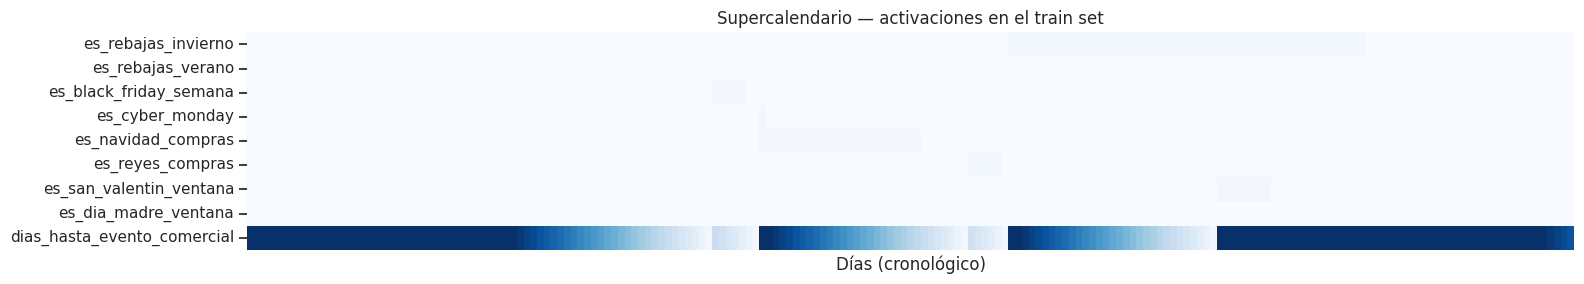

In [6]:
cal_rows = pd.DataFrame(
    [get_calendario_features(f) for f in train['fecha']],
    index=train.index
)
for col in CALENDARIO_FEATURE_COLS:
    train[col] = cal_rows[col].values

print(f'Columnas supercalendario: {CALENDARIO_FEATURE_COLS}')
print()

# Activaciones por evento en el periodo de train
activ = train[CALENDARIO_FEATURE_COLS].sum().sort_values(ascending=False)
print('Días activos por evento en el train set:')
display(activ.to_frame('días_activos'))

# Heatmap de activaciones a lo largo del tiempo
fig, ax = plt.subplots(figsize=(16, 3))
hm_data = train.set_index('fecha')[CALENDARIO_FEATURE_COLS].T
sns.heatmap(hm_data, ax=ax, cbar=False, cmap='Blues', linewidths=0,
            xticklabels=False, yticklabels=True)
ax.set_title('Supercalendario — activaciones en el train set', fontsize=12)
ax.set_xlabel('Días (cronológico)')
plt.tight_layout()
plt.show()

## Fase 6 — Matriz final + correlaciones con el target

In [ ]:
FEATURES = BASE_FEATURES + CALENDARIO_FEATURE_COLS
print(f'Total features: {len(FEATURES)}')
print(f'  Base         : {len(BASE_FEATURES)}')
print(f'  Supercal     : {len(CALENDARIO_FEATURE_COLS)}')
print(f'\nShape X_train  : {train[FEATURES].shape}')
print(f'Shape y_train  : {train["total_visits"].shape}')
print()
display(train[FEATURES].describe().round(2))

# Correlaciones con target
corrs = (
    train[FEATURES + ['total_visits']]
    .corr()['total_visits']
    .drop('total_visits')
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, len(FEATURES) * 0.35 + 1))
colors = ['#27ae60' if v > 0 else '#e74c3c' for v in corrs.values]
ax.barh(corrs.index, corrs.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de Pearson feature → total_visits', fontsize=12)
ax.set_xlabel('Correlación')
plt.tight_layout()
plt.show()

## Fase 7 — Split temporal + Entrenamiento XGBoost

Train interno : 167 filas  (2025-09-16 → 2026-03-01)
Val interno   : 30 filas  (2026-03-02 → 2026-03-31)

Entrenando...
Early stop en iteración: 67


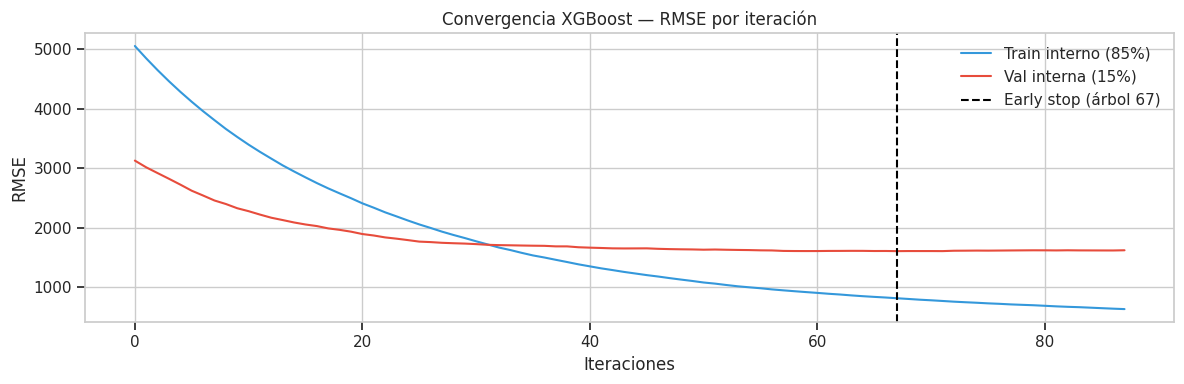

In [9]:
X_all, y_all = train[FEATURES], train['total_visits']
split_idx    = int(len(X_all) * 0.85)

X_t, y_t = X_all.iloc[:split_idx], y_all.iloc[:split_idx]
X_v, y_v = X_all.iloc[split_idx:], y_all.iloc[split_idx:]

print(f'Train interno : {len(X_t)} filas  ({train["fecha"].iloc[0].date()} → {train["fecha"].iloc[split_idx-1].date()})')
print(f'Val interno   : {len(X_v)} filas  ({train["fecha"].iloc[split_idx].date()} → {train["fecha"].iloc[-1].date()})')

modelo = xgb.XGBRegressor(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    early_stopping_rounds=20,
)
print('\nEntrenando...')
modelo.fit(X_t, y_t, eval_set=[(X_t, y_t), (X_v, y_v)], verbose=False)
print(f'Early stop en iteración: {modelo.best_iteration}')

# Curva de entrenamiento
res    = modelo.evals_result()
epochs = range(len(res['validation_0']['rmse']))
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(epochs, res['validation_0']['rmse'], label='Train interno (85%)', color='#3498db')
ax.plot(epochs, res['validation_1']['rmse'], label='Val interna (15%)',   color='#e74c3c')
ax.axvline(modelo.best_iteration, color='black', linestyle='--', linewidth=1.5,
           label=f'Early stop (árbol {modelo.best_iteration})')
ax.set_title('Convergencia XGBoost — RMSE por iteración', fontsize=12)
ax.set_xlabel('Iteraciones')
ax.set_ylabel('RMSE')
ax.legend()
plt.tight_layout()
plt.show()

## Fase 8 — Importancia de features

In [ ]:
importancias = pd.Series(
    modelo.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

def color_grupo(feat):
    if feat in CALENDARIO_FEATURE_COLS: return '#9b59b6'
    return '#3498db'

colors = [color_grupo(f) for f in importancias.index]

fig, ax = plt.subplots(figsize=(10, len(FEATURES) * 0.35 + 1))
ax.barh(importancias.index, importancias.values, color=colors)
ax.set_title('Importancia de features (gain)\n🔵 base  🟣 supercalendario', fontsize=12)
ax.set_xlabel('Importancia relativa')

from matplotlib.patches import Patch

legend = [
    Patch(color='#3498db', label='Base'),
    Patch(color='#9b59b6', label='Supercalendario'),
]
ax.legend(handles=legend, loc='lower right')
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
display(importancias.sort_values(ascending=False).head(10).to_frame('importancia').round(4))

## Fase 9 — Predicción autorregresiva (backtesting)

In [ ]:
df_work = df_tienda[df_tienda['fecha'] < FECHA_CORTE].copy()
fechas_pred, valores_pred, valores_reales = [], [], []

for i in range(HORIZONTE):
    current_date = FECHA_CORTE + timedelta(days=i)
    fechas_pred.append(current_date)

    real_row   = df_tienda[df_tienda['fecha'] == current_date]
    tiene_real = not real_row.empty
    llueve     = real_row['llueve'].values[0]    if tiene_real else 0
    t_max      = real_row['temp_max'].values[0]  if tiene_real else 22.0
    t_min      = real_row['temp_min'].values[0]  if tiene_real else 12.0
    real_visits= real_row['total_visits'].values[0] if tiene_real else np.nan
    valores_reales.append(real_visits)

    es_festivo = 1 if current_date in festivos_espana else 0
    es_finde   = 1 if current_date.dayofweek in [5, 6] else 0

    v = df_work['total_visits'].values
    lag_1d    = v[-1]  if len(v) >=  1 else 0
    lag_7d    = v[-7]  if len(v) >=  7 else 0
    lag_14d   = v[-14] if len(v) >= 14 else 0
    media_7d  = np.mean(v[-7:])  if len(v) >=  7 else 0
    media_14d = np.mean(v[-14:]) if len(v) >= 14 else 0
    std_7d    = np.std(v[-7:])   if len(v) >=  7 else 0

    cal_feats = get_calendario_features(current_date)

    row = pd.DataFrame([{
        'es_finde': es_finde, 'es_festivo': es_festivo, 'llueve': llueve,
        'dia_semana': current_date.dayofweek, 'dia_mes': current_date.day, 'mes': current_date.month,
        'lag_1d': lag_1d, 'lag_7d': lag_7d, 'media_7d': media_7d,
        'quincena': 1 if current_date.day > 15 else 0,
        'vispera_festivo': 1 if (current_date + timedelta(days=1)) in festivos_espana else 0,
        'lag_14d': lag_14d, 'media_14d': media_14d, 'std_7d': std_7d,
        'finde_lluvioso': es_finde * llueve,
        'mucho_calor': 1 if t_max >= 32.0 else 0,
        'mucho_frio':  1 if t_min <= 8.0  else 0,
        'clima_ideal': 1 if (18.0 <= t_max <= 26.0 and llueve == 0) else 0,
        **cal_feats,
    }])

    pred = np.maximum(0, np.round(modelo.predict(row[FEATURES])[0]))
    valores_pred.append(pred)
    df_work = pd.concat(
        [df_work, pd.DataFrame({'fecha': [current_date], 'total_visits': [pred]})],
        ignore_index=True
    )

df_res = pd.DataFrame({'fecha': fechas_pred, 'real': valores_reales, 'pred': valores_pred})
print('Matriz de predicción:')
display(df_res)

## Fase 10 — Evaluación de métricas

Días evaluados : 14
MAE            : 2170.4 visitas
WMAPE          : 16.91%
Accuracy       : 83.09%
Sesgo medio    : -496.7 visitas (+ sobreestima, - subestima)


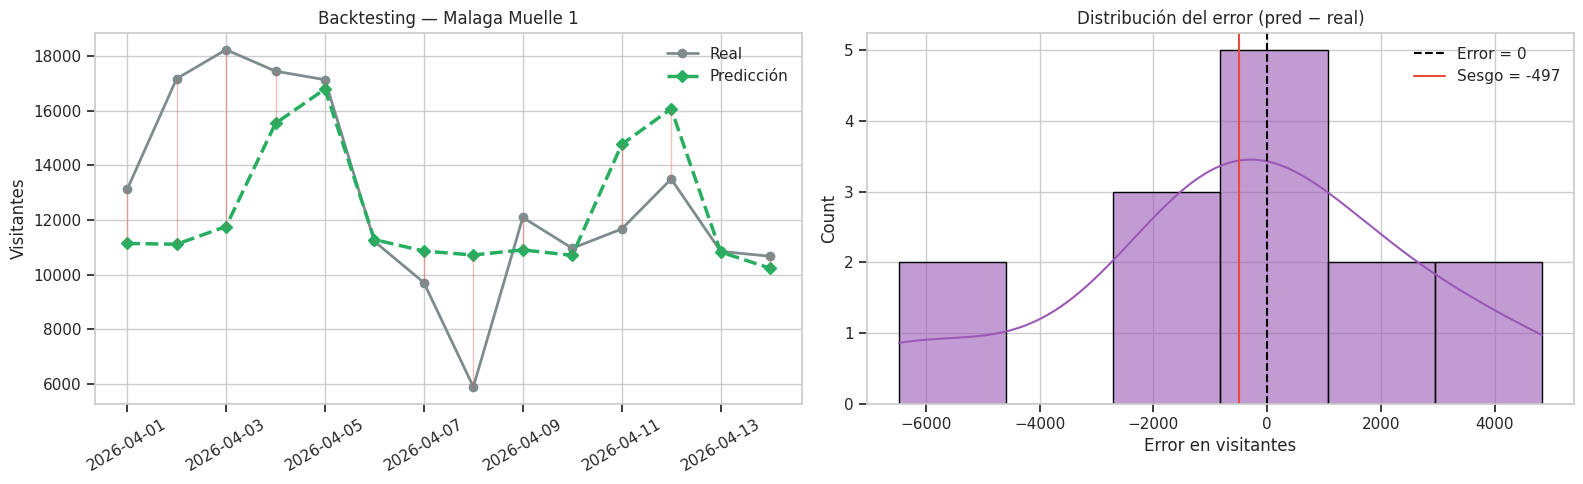

In [12]:
df_eval = df_res.dropna(subset=['real'])
reales  = df_eval['real'].values
predic  = df_eval['pred'].values

mae   = mean_absolute_error(reales, predic)
wmape = np.sum(np.abs(reales - predic)) / np.sum(reales)
acc   = (1 - wmape) * 100
sesgo = np.mean(predic - reales)

print(f'Días evaluados : {len(df_eval)}')
print(f'MAE            : {mae:.1f} visitas')
print(f'WMAPE          : {wmape*100:.2f}%')
print(f'Accuracy       : {acc:.2f}%')
print(f'Sesgo medio    : {sesgo:+.1f} visitas (+ sobreestima, - subestima)')

# Gráfico pred vs real
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(df_res['fecha'], df_res['real'], marker='o', label='Real',
         color='#7f8c8d', linewidth=2)
ax1.plot(df_res['fecha'], df_res['pred'], marker='D', linestyle='--', label='Predicción',
         color='#27ae60', linewidth=2.5)
for _, row in df_eval.iterrows():
    ax1.plot([row['fecha'], row['fecha']], [row['real'], row['pred']],
             color='#e74c3c', alpha=0.35, linewidth=1)
ax1.set_title(f'Backtesting — {nombre_loc}', fontsize=12)
ax1.set_ylabel('Visitantes')
ax1.legend()
ax1.tick_params(axis='x', rotation=30)

# Distribución del error
errores = predic - reales
sns.histplot(errores, ax=ax2, kde=True, color='#9b59b6', alpha=0.6)
ax2.axvline(0,      color='black', linestyle='--', linewidth=1.5, label='Error = 0')
ax2.axvline(sesgo,  color='#e74c3c', linestyle='-',  linewidth=1.5, label=f'Sesgo = {sesgo:+.0f}')
ax2.set_title('Distribución del error (pred − real)', fontsize=12)
ax2.set_xlabel('Error en visitantes')
ax2.legend()

plt.tight_layout()
plt.show()